# Tutorial 02: KernelSHAP with an explicit output contract

This tutorial is deterministic, offline, and designed for a fast CPU run. It uses scikit-learn's built-in Iris dataset, the current Explainiverse adapter API, and the official `shap.KernelExplainer` through `ShapExplainer`. It contains no download or package-install steps.

By the end, you will be able to:

- define the empirical background used by KernelSHAP;
- explain exactly one model-output column with `top_labels=1`;
- identify the output and score space recorded in explanation metadata; and
- numerically check local additivity and seeded repeatability.

> Execution status: remediated and ready for a clean execution. Outputs are intentionally absent from the source notebook.

## 1. What KernelSHAP estimates

For a chosen model output, KernelSHAP fits a locally weighted linear surrogate over feature coalitions. The resulting values $\phi_j$ satisfy the fitted additive decomposition

$$g(f(x)) \approx \phi_0 + \sum_j \phi_j,$$

where $\phi_0$ is the background reference value and $g$ is the configured link. This tutorial uses the identity link, so every term is in probability space.

The explanation is local to one row, one output column, one background dataset, and one KernelSHAP configuration. Additivity is an estimator contract; it is not evidence that the explanation is causal, globally representative, or faithful under arbitrary perturbations.

## 2. Reproducible local setup

Run this notebook from the repository environment, where Explainiverse and its declared tutorial dependencies are already installed.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import shap
import sklearn
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import explainiverse
from explainiverse.adapters import SklearnAdapter
from explainiverse.explainers.attribution import ShapExplainer

SEED = 17
random.seed(SEED)
np.random.seed(SEED)

print(f"Explainiverse {explainiverse.__version__}")
print(f"scikit-learn {sklearn.__version__}; SHAP {shap.__version__}")

Explainiverse 0.14.0
scikit-learn 1.7.2; SHAP 0.52.0


## 3. Train a small probabilistic classifier

Iris has four numerical features and three classes. The small feature space keeps KernelSHAP's coalition regression quick, while multiclass probabilities make the output-index contract visible. The fixed stratified split and fixed model seed make this example reproducible.

In [2]:
iris = load_iris()
X = np.asarray(iris.data, dtype=float)
y = np.asarray(iris.target, dtype=int)
feature_names = [str(name) for name in iris.feature_names]
class_names = [str(name) for name in iris.target_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500, random_state=SEED),
)
model.fit(X_train, y_train)

test_accuracy = accuracy_score(y_test, model.predict(X_test))
test_probabilities = model.predict_proba(X_test)
assert X.shape == (150, 4)
assert test_probabilities.shape == (len(X_test), len(class_names))
np.testing.assert_allclose(test_probabilities.sum(axis=1), 1.0, atol=1e-12)
assert test_accuracy >= 0.85
print(f"Test accuracy: {test_accuracy:.3f} on {len(X_test)} held-out rows")

Test accuracy: 0.921 on 38 held-out rows


## 4. Define the adapter and empirical background

A KernelSHAP background is not merely a speed knob: it defines the reference distribution used when features are treated as absent. Here we take four fixed training rows from each class. That balanced 12-row sample is convenient for a tutorial, but it is not a claim about a real deployment population.

In [3]:
adapter = SklearnAdapter(
    model,
    feature_names=feature_names,
    class_names=class_names,
    task="classification",
)

background_indices = np.concatenate(
    [np.flatnonzero(y_train == class_index)[:4] for class_index in model.classes_]
)
background = X_train[background_indices].copy()
background_probabilities = adapter.predict(background)

assert background.shape == (12, X.shape[1])
assert background_probabilities.shape == (12, len(class_names))
np.testing.assert_allclose(background_probabilities.sum(axis=1), 1.0, atol=1e-12)
print("Background rows per class:", np.bincount(y_train[background_indices]).tolist())

Background rows per class: [4, 4, 4]


## 5. Configure KernelSHAP

The wrapper delegates estimation to the official SHAP implementation. We state every consequential choice: classification semantics, identity link, a fixed coalition budget, no feature-selection regularization, and a fixed seed. `l1_reg=0.0` retains a value for every feature instead of inheriting a SHAP-version-dependent sparsification default.

In [4]:
kernel_shap = ShapExplainer(
    adapter,
    background_data=background,
    feature_names=feature_names,
    class_names=class_names,
    task="classification",
    link="identity",
    nsamples=64,
    l1_reg=0.0,
    random_state=SEED,
)

assert kernel_shap.output_space == "probability"
assert kernel_shap.n_outputs == len(class_names)

## 6. Explain exactly one output

`target_class` is a zero-based model-output column index, not a raw class label. We choose the model's highest-probability output explicitly. `explain` returns one `Explanation`, so the current contract requires `top_labels=1`; use another explicit `target_class` call to study a different output.

In [5]:
instance = X_test[0].copy()
prediction = adapter.predict(instance.reshape(1, -1))[0]
target_index = int(np.argmax(prediction))

explanation = kernel_shap.explain(
    instance,
    top_labels=1,
    target_class=target_index,
)

attribution_map = explanation.explanation_data["feature_attributions"]
shap_values = np.asarray(
    [attribution_map[name] for name in feature_names],
    dtype=float,
)

assert explanation.metadata["output_index"] == target_index
assert explanation.target_class == class_names[target_index]
assert explanation.metadata["output_space"] == "probability"
assert shap_values.shape == (len(feature_names),)
assert np.isfinite(shap_values).all()

print("Class probabilities:")
for name, probability in zip(class_names, prediction):
    marker = " <- explained output" if name == explanation.target_class else ""
    print(f"  {name:10s} {probability:.6f}{marker}")

print("\nAttributions in probability space:")
for name, value in sorted(attribution_map.items(), key=lambda item: -abs(item[1])):
    print(f"  {name:25s} {value:+.6f}")

Class probabilities:
  setosa     0.002527
  versicolor 0.686957 <- explained output
  virginica  0.310516

Attributions in probability space:
  petal width (cm)          +0.149159
  sepal width (cm)          +0.085586
  petal length (cm)         +0.085047
  sepal length (cm)         +0.031842


## 7. Check the numerical contract

With an identity link, the expected value and feature attributions should reconstruct the selected class probability. We also verify that the expected value equals the selected output averaged over this exact background. These checks catch output-axis mistakes and score-space confusion; they do not independently validate the background choice or real-world usefulness.

In [6]:
expected_value = float(explanation.explanation_data["expected_value"])
selected_probability = float(prediction[target_index])
reconstructed_probability = expected_value + float(shap_values.sum())
background_reference = float(background_probabilities[:, target_index].mean())
metadata = explanation.metadata

np.testing.assert_allclose(expected_value, background_reference, rtol=0.0, atol=1e-12)
np.testing.assert_allclose(
    metadata["model_reference_value"], selected_probability, rtol=0.0, atol=1e-12
)
np.testing.assert_allclose(
    metadata["explained_value"], reconstructed_probability, rtol=0.0, atol=1e-12
)
np.testing.assert_allclose(
    reconstructed_probability, selected_probability, rtol=0.0, atol=1e-8
)
assert abs(float(metadata["additivity_residual"])) <= 1e-8

print(f"Background reference       : {expected_value:.8f}")
print(f"Sum of SHAP values        : {shap_values.sum():+.8f}")
print(f"Reconstructed probability : {reconstructed_probability:.8f}")
print(f"Model probability         : {selected_probability:.8f}")
print(f"Additivity residual       : {metadata['additivity_residual']:+.3e}")

Background reference       : 0.33532369
Sum of SHAP values        : +0.35163361
Reconstructed probability : 0.68695730
Model probability         : 0.68695730
Additivity residual       : +0.000e+00


## 8. Check seeded repeatability

The wrapper isolates and restores NumPy's global random state while using `random_state` for KernelSHAP sampling. Repeating the same configured call should therefore reproduce the same values. Repeatability is not the same as stability across seeds, backgrounds, models, or nearby inputs.

In [7]:
repeat = kernel_shap.explain(
    instance,
    top_labels=1,
    target_class=target_index,
)
repeat_values = np.asarray(repeat.explanation_data["shap_values_raw"], dtype=float)
np.testing.assert_array_equal(repeat_values, shap_values)
assert repeat.metadata["random_state"] == SEED
print("Seeded repeatability check passed.")

Seeded repeatability check passed.


## 9. Visualize the selected-output attributions

Positive bars move the additive reconstruction above the background reference for the selected output; negative bars move it below. Magnitude is local to this row and this probability output.

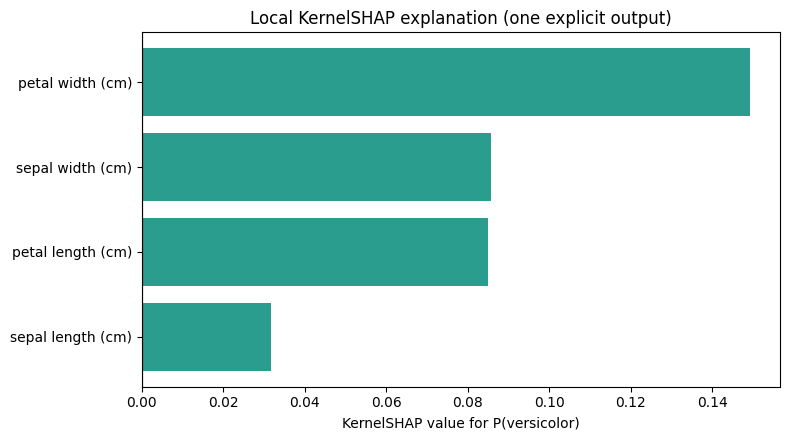

In [8]:
order = np.argsort(np.abs(shap_values))
ordered_values = shap_values[order]
ordered_names = np.asarray(feature_names, dtype=object)[order]
colors = np.where(ordered_values >= 0.0, "#2a9d8f", "#e76f51")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(ordered_names, ordered_values, color=colors)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set_xlabel(f"KernelSHAP value for P({explanation.target_class})")
ax.set_title("Local KernelSHAP explanation (one explicit output)")
fig.tight_layout()
plt.show()

## 10. Interpretation boundaries and next checks

What this notebook establishes:

- the Explainiverse wrapper selected the intended probability column;
- the returned vector has one finite value per input feature;
- the values satisfy the recorded identity-link additive decomposition; and
- the fixed configuration is repeatable.

What it does **not** establish:

- **Causality:** coalition substitutions are model queries, not interventions on the real world.
- **A conditional feature game:** the empirical-background masker may create unrealistic combinations when features are dependent.
- **Population representativeness:** twelve balanced Iris rows are a teaching choice, not a deployment reference distribution.
- **Global importance:** one local attribution vector must not be presented as cohort- or model-level importance.
- **General stability or correctness:** additivity and one seeded repeat do not test sensitivity to alternative backgrounds, seeds, preprocessing, models, or neighboring observations.
- **Scalability:** coalition cost grows quickly with feature count; this four-feature example is intentionally small.

Useful extensions are to prespecify several defensible background samples, repeat the analysis across seeds when sampling is active, explain the same row for each explicit output index, and report how conclusions change. Keep each comparison in the same output and link space.

### References

- Lundberg, S. M., & Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.
- SHAP documentation: `shap.KernelExplainer`.
- Explainiverse implementation: `explainiverse.explainers.attribution.ShapExplainer`.